# HydroSeason — Hydrological Season Delineation
## Application to Tayer et al. (2026) DATASET2

This notebook demonstrates the full **HydroSeason** workflow on the 443-month record
(Dec 1986 – Oct 2023) published in Tayer et al. (2026). The delineation input is
**only** `Rainfall_mm`; the additional DATASET2 hydrology/morphology columns are
used later to compare end-of-dry metrics against the paper.

The final sections compare the refactored, fully data-driven output against the
paper's original season, hydro-year, rainfall, zero-flow, and end-of-dry metric outputs.

---

### What this notebook covers
| Section | Topic |
|---------|-------|
| 1 | Setup & imports |
| 2 | Load & validate DATASET2 |
| 3 | One-liner API — `df.hydroseason.classify_rainfall_df()` |
| 4 | Full pipeline with diagnostics |
| 5 | Algorithm deep-dive (STL, Walsh-Lawler SI, circular climatology) |
| 6 | Step-by-step delineation |
| 7 | Visualisation (4 standard figures + dashboard) |
| 8 | Comparison with the paper's original output and DATASET2 metrics |
| 9 | Config-file workflow |
| 10 | Export & next steps |

## 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import sys, pathlib
# Ensure the repo root is on the path when running from notebooks/ or tests/.
repo_root = pathlib.Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Plot cells use Plotly; later comparison cells use Matplotlib.
%pip install plotly matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# HydroSeason - importing the package registers the df.hydroseason accessor.
import hydroseason
from hydroseason import (
    classify_rainfall,
    classify,
    validate_monthly_input,
    detect_seasonality_regime,
    circular_climatology,
    stl_seasonality_strength,
    walsh_lawler_seasonality_index,
    plot_season_timeline,
    plot_mean_monthly_rainfall,
    plot_stl_decomposition,
    plot_annual_metrics,
    plot_dashboard,
)

# Nice defaults
mpl.rcParams.update({'figure.dpi': 120, 'font.size': 10})
%matplotlib inline
print(f'pandas {pd.__version__}  |  numpy {np.__version__}  |  HydroSeason loaded OK')

Note: you may need to restart the kernel to use updated packages.
pandas 2.2.3  |  numpy 1.26.4  |  HydroSeason loaded OK


## 2 — Load & validate the paper dataset

The full dataset (`DATASET.csv`) contains the paper's original output columns.
We first strip it down to the three input columns (`Date`, `Year`, `Month`, `Rainfall_mm`)
so `HydroSeason` receives only what a user would provide in a typical application.

In [2]:
# ── Load the full paper dataset (reference + hydrological/morphology metrics)
paper_full = pd.read_csv('../tests/fixtures/DATASET2.csv')
paper_full['Date'] = pd.to_datetime(paper_full['Date'], dayfirst=True)
paper_full['Date'] = paper_full['Date'].dt.strftime('%Y-%m-%d')

# ── Input-only view (what any user would provide)
input_df = paper_full[['Date', 'Year', 'Month', 'Rainfall_mm']].copy()

print(f'Rows : {len(input_df)}')
print(f'Range: {input_df["Date"].iloc[0]}  →  {input_df["Date"].iloc[-1]}')
print(f'Mean annual rainfall: {input_df["Rainfall_mm"].sum() / (len(input_df)/12):.0f} mm/yr')
print('Additional DATASET2 metric columns:', [c for c in paper_full.columns if c.endswith('_endDry')])
input_df.head()

Rows : 443
Range: 1986-12-01  →  2023-10-01
Mean annual rainfall: 770 mm/yr
Additional DATASET2 metric columns: ['wet_area_ha_endDry', 'npools_endDry', 'AWMPA_endDry', 'AWMPL_endDry', 'AWMPW_endDry', 'PF_endDry', 'MPA_endDry']


,Date,Year,Month,Rainfall_mm
0,1986-12-01,1986,12,26.5
1,1987-01-01,1987,1,214.5
2,1987-02-01,1987,2,220.5
3,1987-03-01,1987,3,149.5
4,1987-04-01,1987,4,2.5


In [3]:
# ── Validation report
cleaned, report = validate_monthly_input(input_df)

print('=== Validation Report ===')
print(f'OK            : {report.ok}')
print(f'Rows in/out   : {report.n_rows_in} / {report.n_rows_out}')
print(f'Imputed       : {report.n_imputed}')
print(f'Inferred freq : {report.inferred_freq}')
print(f'Errors        : {report.errors or "none"}')
print(f'Warnings      : {report.warnings or "none"}')

=== Validation Report ===
OK            : True
Rows in/out   : 443 / 443
Imputed       : 0
Inferred freq : MS
Errors        : none
Warnings      : none


## 3 — One-liner API

Two equivalent one-liners — use whichever feels most natural.

In [4]:
# Pandas accessor style
result_accessor = input_df.hydroseason.classify_rainfall_df()

# Module-level function style
result_fn = classify(input_df)

print('Columns:', result_accessor.columns.tolist())
result_accessor[['Date', 'Year', 'Month', 'Rainfall_mm',
                  'SeasonType', 'SeasonShift', 'Hydro_Year']].head(12)

Columns: ['Date', 'Year', 'Month', 'Rainfall_mm', 'Hydro_Year_fixed', 'Smoothed', 'Significant', 'SeasonType', 'SeasonShift', 'Hydro_Year', 'Seasonality_SI', 'Seasonality_STL', 'Seasonality_Regime', 'dry_event_count', 'dry_total', 'wet_total', 'dry_month_count', 'wet_month_count', 'Dry_season_rain_count', 'Rain_dry_season_mm', 'Rain_wet_season_mm', 'Dry_month_count']


,Date,Year,Month,Rainfall_mm,SeasonType,SeasonShift,Hydro_Year
0,1986-12-01,1986,12,26.5,Wet,True,1987
1,1987-01-01,1987,1,214.5,Wet,False,1987
2,1987-02-01,1987,2,220.5,Wet,False,1987
3,1987-03-01,1987,3,149.5,Wet,False,1987
4,1987-04-01,1987,4,2.5,Wet,False,1987
5,1987-05-01,1987,5,29.0,Wet,False,1987
6,1987-06-01,1987,6,0.0,Dry,True,1987
7,1987-07-01,1987,7,0.0,Dry,False,1987
8,1987-08-01,1987,8,0.0,Dry,False,1987
9,1987-09-01,1987,9,0.0,Dry,False,1987


## 4 — Full pipeline run with diagnostics

`classify_rainfall` returns a `PipelineArtifacts` namedtuple that
exposes intermediate results at every stage.

In [20]:
artifacts = classify_rainfall(
    input_df,
    # All of these are optional; shown here for explicitness
    value_col='Rainfall_mm',
    date_col='Date',
    year_col='Year',
    month_col='Month',
    method='circular',           # circular | kmeans
    smooth_window=3,             # paper spec
    firstpass_quantile=0.20,
    secondpass_quantile=0.10,
    long_period_threshold=16,
    onset_window_months=1,       # count only plausible Oct-Dec onsets for a Nov baseline
    fallback_month=None,         # auto-derived from data
    rainfall_si_override=True,   # promote borderline STL to seasonal when Walsh-Lawler SI is strongly seasonal
)

result = artifacts.result
diag   = artifacts.diagnostics

print('=== Diagnostics ===')
for k, v in vars(diag).items():
    print(f'  {k:<30} {v}')


=== Diagnostics ===
  regime                         seasonal
  regime_source                  rainfall_si_override
  stl_strength                   0.567519232143832
  walsh_lawler_si                1.007264765714609
  kmeans_silhouette              None
  circular_R                     0.7234662651559411
  is_bimodal                     True
  is_uniform                     False
  hydro_year_start_month         11
  fallback_month_used            9
  threshold_firstpass            11.960000000000003
  threshold_secondpass           4.6
  rainfall_si_override           True
  validation_warnings            []
  n_input_rows                   443
  n_rows_after_validation        443
  n_imputed                      0


## 5 — Algorithm deep-dive

### 5.1 STL seasonality strength and the rainfall SI override

$$F_S = \max\left(0,\; 1 - \frac{\mathrm{Var}(R)}{\mathrm{Var}(R + S)}\right)$$

where $R$ is the STL remainder and $S$ is the seasonal component.  
Generic STL thresholds: $F_S < 0.30$ → **non-seasonal**, $0.30 \leq F_S < 0.60$ → **borderline**, $F_S \geq 0.60$ → **seasonal**.

For rainfall, raw monthly totals are highly skewed: a few extreme wet-season months inflate STL remainder variance. HydroSeason therefore keeps STL as the transferable base metric, but auto-enables a rainfall-specific Walsh-Lawler SI override when the input column looks like rainfall/precipitation. In this dataset, raw STL is borderline, but SI is strongly seasonal, so the pipeline correctly treats the catchment as seasonal.

In [6]:
from hydroseason.seasonality import (
    stl_seasonality_strength,
    walsh_lawler_seasonality_index,
    mean_monthly_rainfall,
    classify_regime_from_stl,
    classify_regime_with_rainfall_si,
)
from statsmodels.tsa.seasonal import STL

cleaned['Date'] = pd.to_datetime(cleaned['Date'])
fs = stl_seasonality_strength(cleaned)
clim = mean_monthly_rainfall(cleaned)
si = walsh_lawler_seasonality_index(clim.values)
hybrid_regime, hybrid_source = classify_regime_with_rainfall_si(fs, si)

# Variance-stabilised checks: these show that the borderline raw STL value is caused by rainfall skew.
s = cleaned.set_index('Date').asfreq('MS')['Rainfall_mm']
def _stl_strength_from_series(series):
    fit = STL(series, period=12, robust=True).fit()
    var_r = float(np.var(fit.resid))
    var_rs = float(np.var(fit.resid + fit.seasonal))
    return max(0, 1 - var_r / var_rs) if var_rs else 0

fs_log1p = _stl_strength_from_series(np.log1p(s))
fs_sqrt = _stl_strength_from_series(np.sqrt(s))

print(f'Raw STL F_S                 = {fs:.3f}  → {classify_regime_from_stl(fs)}')
print(f'Walsh-Lawler SI             = {si:.3f}')
print(f'Hybrid rainfall regime      = {hybrid_regime}  (source: {hybrid_source})')
print(f'log1p rainfall STL F_S      = {fs_log1p:.3f}')
print(f'sqrt rainfall STL F_S       = {fs_sqrt:.3f}')

Raw STL F_S                 = 0.568  → borderline
Walsh-Lawler SI             = 1.007
Hybrid rainfall regime      = seasonal  (source: rainfall_si_override)
log1p rainfall STL F_S      = 0.636
sqrt rainfall STL F_S       = 0.660


In [7]:
# Full SeasonalityResult
seas_result = detect_seasonality_regime(cleaned)
print(seas_result)

SeasonalityResult(stl_strength=0.567519232143832, si=1.007264765714609, regime='seasonal', silhouette=None, regime_source='rainfall_si_override')


### 5.2 Circular climatology

Months are placed on a unit circle at angles $\theta_m = 2\pi(m-1)/12$.  
The resultant vector length $R$ measures concentration; $R < 0.10$ → **uniform** (perennial).  
The ratio of the 2nd Fourier harmonic to the 1st detects **bimodal** regimes.

In [8]:
from hydroseason.fixed_season import circular_stats

clim_df, start_month, circ = circular_climatology(cleaned)

print(f'Peak month           : {circ.peak_month}')
print(f'Circular mean month  : {circ.peak_angle_month:.1f}')
print(f'Concentration R      : {circ.concentration_R:.3f}  (1=perfect unimodal, 0=uniform)')
print(f'2nd harmonic ratio   : {circ.second_harmonic_ratio:.3f}  (>0.5 = bimodal)')
print(f'Bimodal              : {circ.is_bimodal}')
print(f'Uniform              : {circ.is_uniform}')
print(f'Hydro-year start month → {start_month}')
print()
print(clim_df[['mean', 'Season']])

Peak month           : 1
Circular mean month  : 1.4
Concentration R      : 0.723  (1=perfect unimodal, 0=uniform)
2nd harmonic ratio   : 0.521  (>0.5 = bimodal)
Bimodal              : True
Uniform              : False
Hydro-year start month → 11

             mean Season
Month                   
1      226.656757    Wet
2      192.935946    Wet
3      102.398919    Wet
4       22.845946    Wet
5       19.045946    Dry
6        7.832432    Dry
7        8.924324    Dry
8        2.097297    Dry
9        3.545946    Dry
10      12.767568    Dry
11      48.422222    Wet
12     122.191081    Wet


## 6 — Step-by-step pipeline walkthrough

Demonstrates what each step adds to the DataFrame.

In [9]:
from hydroseason.hydro_year import assign_fixed_hydro_year
from hydroseason.dynamic_season import (
    harmonize_with_zero_preservation,
    segment_main_wet_season_fixed_threshold,
    refine_season_tails,
)
from hydroseason.hydro_year import assign_hydro_years
from hydroseason.metrics import compute_season_metrics
from hydroseason.fixed_season import hydro_year_start_after_min_month

# Step 1 — Fixed hydro year from circular climatology
step1 = assign_fixed_hydro_year(cleaned, start_month=start_month)
print('After Step 1 (fixed hydro year):', step1.columns.tolist())

# Step 2 — Zero-preserving smooth
step2 = harmonize_with_zero_preservation(step1, window=3)
print('After Step 2 (smooth):', [c for c in step2.columns if c not in step1.columns])

# Step 3 — First-pass segmentation
nonzero_rain = step2[step2['Rainfall_mm'] > 0]['Rainfall_mm']
threshold_p20 = float(nonzero_rain.quantile(0.20))
print(f'\n20th pctile threshold (first pass): {threshold_p20:.1f} mm')
step3, wet_boundaries = segment_main_wet_season_fixed_threshold(step2, threshold=threshold_p20)
print('Wet season boundaries (first 5):')
print(wet_boundaries.head())

After Step 1 (fixed hydro year): ['Date', 'Year', 'Month', 'Rainfall_mm', 'Hydro_Year_fixed']
After Step 2 (smooth): ['Smoothed']

20th pctile threshold (first pass): 12.0 mm
Wet season boundaries (first 5):
   Hydro_Year    WetStart      WetEnd  wet_duration_months
0        1987  1986-12-01  1987-04-01                    5
1        1988  1987-11-01  1988-02-01                    4
2        1989  1988-11-01  1989-07-01                    9
3        1990  1989-11-01  1990-06-01                    8
4        1991  1990-11-01  1991-02-01                    4


In [10]:
# Step 4 — Two-threshold hysteresis tail refinement
nonzero_after = step3[step3['Rainfall_mm'] > 0]['Rainfall_mm']
threshold_p10 = float(nonzero_after.quantile(0.10)) if len(nonzero_after) else 0.0
print(f'10th pctile threshold (second pass / tail): {threshold_p10:.1f} mm')

step4 = refine_season_tails(
    step3,
    threshold_high=threshold_p20,
    threshold_low=0.0,
)

# Changes from refinement
changed = (step3['SeasonType'] != step4['SeasonType']).sum()
print(f'Months whose season label changed after tail refinement: {changed}')

# Step 5 — Dynamic hydro year
fb_month, _ = hydro_year_start_after_min_month(cleaned)
step5 = assign_hydro_years(step4, hydro_year_start_month=start_month, fallback_month=fb_month)
print(f'Hydro years: {sorted(step5["Hydro_Year"].unique())[:5]} ...')

# Step 6 — Season metrics
step6 = compute_season_metrics(step5)
print('\nMetric columns added:', [c for c in step6.columns if c not in step5.columns])

10th pctile threshold (second pass / tail): 4.6 mm
Months whose season label changed after tail refinement: 28
Hydro years: [1987, 1988, 1989, 1990, 1991] ...

Metric columns added: ['dry_event_count', 'dry_total', 'wet_total', 'dry_month_count', 'wet_month_count', 'Dry_season_rain_count', 'Rain_dry_season_mm', 'Rain_wet_season_mm', 'Dry_month_count']


## 7 — Visualisation

### 7.1 STL decomposition

In [11]:
fig_stl = plot_stl_decomposition(
    cleaned,
    title=f'STL decomposition - Tayer et al. 2026  (F_S = {diag.stl_strength:.3f}, regime: {diag.regime})',
)
fig_stl

### 7.2 Monthly climatology

In [12]:
fig_clim = plot_mean_monthly_rainfall(
    result,
    artifacts.fixed_monthly,
    title=f'Monthly climatology  (peak month {circ.peak_month}, R = {circ.concentration_R:.2f})',
)
fig_clim

### 7.3 Season timeline (full record)

In [13]:
fig_tl = plot_season_timeline(
    result,
    title='Rainfall time series - HydroSeason season classification',
    width=1200,
    height=500,
)
fig_tl

### 7.4 Annual metrics

In [14]:
fig_ann = plot_annual_metrics(
    result,
    title='Annual wet / dry season totals - HydroSeason output',
)
fig_ann

### 7.5 Dashboard (2×2 composite)

In [15]:
fig_dash = plot_dashboard(
    artifacts,
    width=1200,
    height=850,
    title='HydroSeason dashboard - Tayer et al. 2026 dataset',
)
fig_dash

### 7.6 Pandas accessor shortcut

In [16]:
# Once the pipeline has been run and columns exist, accessor methods work directly
# on the result DataFrame with no re-computation needed.
fig = result.hydroseason.plot_timeline(
    title='Accessor -> plot_season_timeline',
    width=1100,
    height=420,
)
print('repr:', result.hydroseason)
fig

repr: <HydroSeasonAccessor rows=443>


## 8 — Comparison with the paper's original output

We compare `SeasonType`, `Hydro_Year`, rainfall metrics, zero-flow metrics, and the DATASET2 end-of-dry river-state metrics. The end-of-dry metrics in DATASET2 are not simply the last two rows labelled Dry in every year; they use the final dry-season minimum in wetted area when the terminal dry month has already rebounded.

In [21]:
# Align on Date
result['Date_dt'] = pd.to_datetime(result['Date'])
paper_full['Date_dt'] = pd.to_datetime(paper_full['Date'])

cmp = result[['Date_dt', 'SeasonType', 'Hydro_Year', 'wet_total', 'dry_total']].merge(
    paper_full[['Date_dt', 'SeasonType', 'Hydro_Year',
                'Rain_wet_season_mm', 'Rain_dry_season_mm']],
    on='Date_dt', suffixes=('_new', '_paper')
)

n = len(cmp)
season_agree   = (cmp['SeasonType_new'] == cmp['SeasonType_paper']).sum()
hy_agree       = (cmp['Hydro_Year_new'] == cmp['Hydro_Year_paper']).sum()

print('=== SeasonType agreement ===')
print(f'  Matching months   : {season_agree} / {n}  ({100*season_agree/n:.1f}%)')
print(f'  Disagreements     : {n - season_agree}')
print()
print('=== Hydro_Year agreement ===')
print(f'  Matching months   : {hy_agree} / {n}  ({100*hy_agree/n:.1f}%)')

=== SeasonType agreement ===
  Matching months   : 432 / 443  (97.5%)
  Disagreements     : 11

=== Hydro_Year agreement ===
  Matching months   : 427 / 443  (96.4%)


In [22]:
# Confusion matrix for SeasonType
ct = pd.crosstab(
    cmp['SeasonType_paper'].rename('Paper'),
    cmp['SeasonType_new'].rename('HydroSeason'),
    margins=True
)
print('Confusion matrix (rows = paper, cols = HydroSeason):')
display(ct)

Confusion matrix (rows = paper, cols = HydroSeason):


HydroSeason,Dry,Wet,All
Paper,,,
Dry,184,4,188
Wet,7,248,255
All,191,252,443


In [23]:
# Months where they disagree — inspect a sample
disagree = cmp[cmp['SeasonType_new'] != cmp['SeasonType_paper']][
    ['Date_dt', 'SeasonType_paper', 'SeasonType_new', 'Hydro_Year_paper', 'Hydro_Year_new']
].reset_index(drop=True)
print(f'Disagreements ({len(disagree)} rows):')
display(disagree.head(20))

Disagreements (11 rows):


,Date_dt,SeasonType_paper,SeasonType_new,Hydro_Year_paper,Hydro_Year_new
0,1995-04-01,Wet,Dry,1995,1995
1,1997-04-01,Wet,Dry,1997,1997
2,2006-08-01,Wet,Dry,2006,2006
3,2009-11-01,Dry,Wet,2009,2010
4,2010-09-01,Dry,Wet,2010,2011
5,2012-04-01,Wet,Dry,2012,2012
6,2012-10-01,Dry,Wet,2012,2013
7,2016-08-01,Wet,Dry,2016,2016
8,2021-09-01,Dry,Wet,2021,2022
9,2022-06-01,Wet,Dry,2022,2022


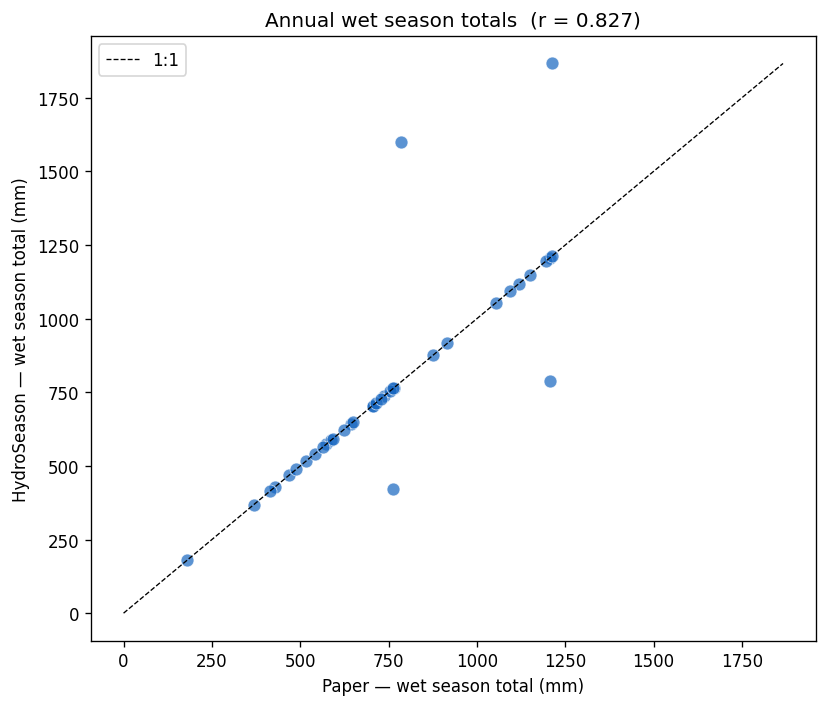

Pearson r = 0.8272


In [24]:
# Per-year wet season total comparison scatter
ann_cmp = cmp.drop_duplicates(subset=['Hydro_Year_new'])[['Hydro_Year_new', 'wet_total', 'Rain_wet_season_mm']]
ann_cmp = ann_cmp.dropna()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(ann_cmp['Rain_wet_season_mm'], ann_cmp['wet_total'],
           c='#1565C0', alpha=0.7, edgecolors='white', linewidth=0.5, s=60)

# 1:1 line
vmax = max(ann_cmp[['Rain_wet_season_mm', 'wet_total']].max())
ax.plot([0, vmax], [0, vmax], 'k--', linewidth=0.8, label='1:1')

corr = ann_cmp['Rain_wet_season_mm'].corr(ann_cmp['wet_total'])
ax.set_xlabel('Paper — wet season total (mm)')
ax.set_ylabel('HydroSeason — wet season total (mm)')
ax.set_title(f'Annual wet season totals  (r = {corr:.3f})')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Pearson r = {corr:.4f}')

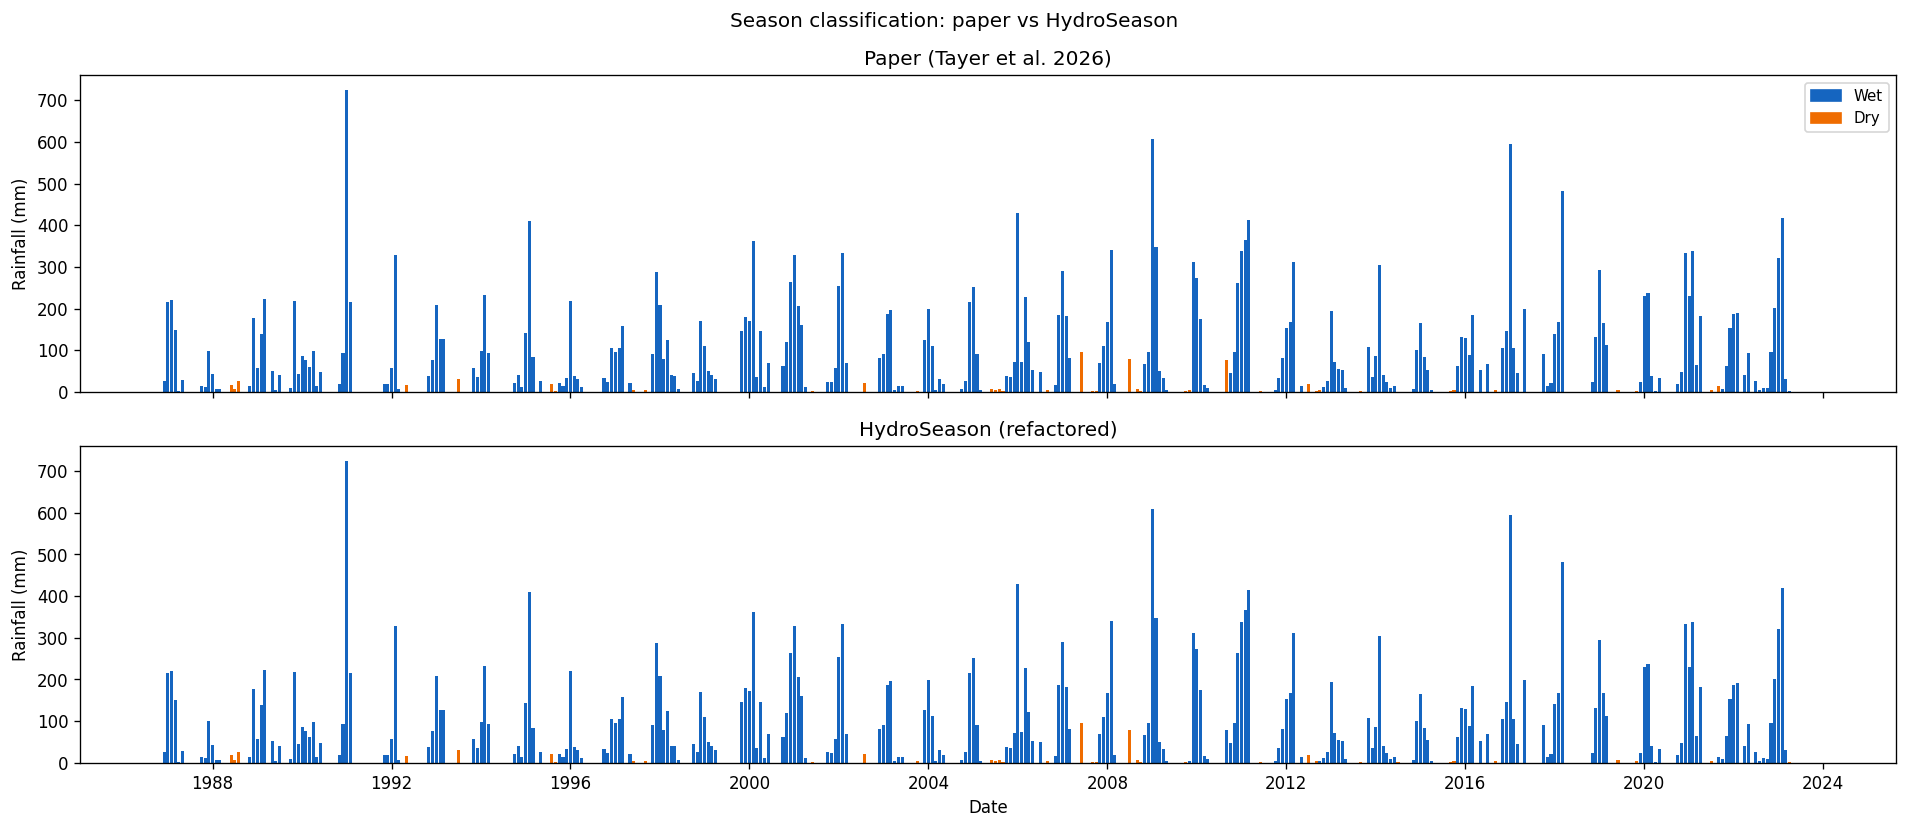

In [25]:
# Side-by-side season timeline: paper vs HydroSeason
paper_full_plot = paper_full.copy()
paper_full_plot['Date'] = paper_full_plot['Date_dt'].dt.strftime('%Y-%m-%d')

from hydroseason.plot import WET_COLOUR, DRY_COLOUR, _season_colour

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for ax_i, (df_i, title_i) in enumerate([
    (paper_full_plot, 'Paper (Tayer et al. 2026)'),
    (result,          'HydroSeason (refactored)'),
]):
    df_plot = df_i.copy()
    df_plot['Date_dt'] = pd.to_datetime(df_plot['Date'])
    colours = df_plot['SeasonType'].map(_season_colour)
    axes[ax_i].bar(df_plot['Date_dt'], df_plot['Rainfall_mm'],
                   color=colours, width=25, linewidth=0)
    axes[ax_i].set_title(title_i)
    axes[ax_i].set_ylabel('Rainfall (mm)')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=WET_COLOUR, label='Wet'),
    mpatches.Patch(color=DRY_COLOUR, label='Dry'),
]
axes[0].legend(handles=legend_patches, fontsize=9, framealpha=0.8, loc='upper right')
axes[-1].set_xlabel('Date')
fig.suptitle('Season classification: paper vs HydroSeason', fontsize=12)
plt.tight_layout()
plt.show()

### 8.4 DATASET2 metric comparison

The paper stores annual end-of-dry metrics as repeated columns on every monthly row. HydroSeason computes the same metrics from the monthly hydrology/morphology variables by averaging the two-month window ending at the terminal dry-season minimum in `wet_area_ha`.

In [26]:
from hydroseason.metrics import compute_end_dry_metrics

metric_cols = ['wet_area_ha', 'npools', 'AWMPA', 'AWMPL', 'AWMPW', 'PF', 'MPA']
end_cols = [f'{c}_endDry' for c in metric_cols]
annual_cols = [
    'Dry_season_rain_count',
    'Rain_dry_season_mm',
    'Rain_wet_season_mm',
    'zero_flow_months_count',
    'Dry_month_count',
] + end_cols

# Attach monthly DATASET2 hydrology/morphology variables to the HydroSeason result
result_metrics = result.copy()
result_metrics['Date'] = pd.to_datetime(result_metrics['Date'])
paper_metrics = paper_full.copy()
paper_metrics['Date'] = pd.to_datetime(paper_metrics['Date'])

monthly_extras = paper_metrics[['Date', 'Discharge'] + metric_cols]
result_metrics = result_metrics.merge(monthly_extras, on='Date', how='left')

# Compute paper-style auxiliary metrics under the HydroSeason season boundaries
# result_metrics = compute_zero_flow_months(result_metrics, threshold=1.0)  # function removed
result_metrics = compute_end_dry_metrics(
    result_metrics,
    metric_cols=metric_cols,
    anchor='terminal_minimum',
    anchor_col='wet_area_ha',
)

# One row per Hydro_Year for comparison
ref_annual = (
    paper_metrics
    .drop_duplicates('Hydro_Year')
    [['Hydro_Year'] + annual_cols]
    .rename(columns={c: f'{c}_paper' for c in annual_cols})
)
new_annual = (
    result_metrics
    .drop_duplicates('Hydro_Year')
    [['Hydro_Year'] + annual_cols]
    .rename(columns={c: f'{c}_hydrots' for c in annual_cols})
)
metric_cmp = ref_annual.merge(new_annual, on='Hydro_Year', how='inner')
print(f'Annual hydro-years compared: {len(metric_cmp)}')

Annual hydro-years compared: 36


In [27]:
rows = []
for metric in annual_cols:
    paper = pd.to_numeric(metric_cmp[f'{metric}_paper'], errors='coerce')
    hydro = pd.to_numeric(metric_cmp[f'{metric}_hydrots'], errors='coerce')
    mask = paper.notna() & hydro.notna()
    diff = hydro[mask] - paper[mask]
    rows.append({
        'metric': metric,
        'n': int(mask.sum()),
        'paper_mean': paper[mask].mean(),
        'hydrots_mean': hydro[mask].mean(),
        'mean_diff': diff.mean(),
        'mean_abs_diff': diff.abs().mean(),
        'median_abs_diff': diff.abs().median(),
        'rmse': np.sqrt((diff * diff).mean()),
        'corr': paper[mask].corr(hydro[mask]) if mask.sum() > 1 else np.nan,
    })

metric_summary = pd.DataFrame(rows)
display(metric_summary.style.format({
    'paper_mean': '{:.3f}',
    'hydrots_mean': '{:.3f}',
    'mean_diff': '{:.3f}',
    'mean_abs_diff': '{:.3f}',
    'median_abs_diff': '{:.3f}',
    'rmse': '{:.3f}',
    'corr': '{:.3f}',
}))

,metric,n,paper_mean,hydrots_mean,mean_diff,mean_abs_diff,median_abs_diff,rmse,corr
0,Dry_season_rain_count,36,1.000,0.917,-0.083,0.139,0.000,0.373,0.942
1,Rain_dry_season_mm,36,14.347,11.631,-2.717,2.828,0.000,13.166,0.860
2,Rain_wet_season_mm,36,745.707,778.068,32.361,32.361,0.000,180.201,0.859
3,zero_flow_months_count,36,4.944,4.583,-0.361,0.694,1.000,1.093,0.879
4,Dry_month_count,36,5.056,5.306,0.250,0.417,0.000,1.404,0.693
5,wet_area_ha_endDry,36,9.541,10.295,0.754,1.113,0.000,3.636,0.931
6,npools_endDry,36,14.986,15.424,0.438,1.299,0.000,4.037,0.928
7,AWMPA_endDry,36,1.450,1.490,0.040,0.040,0.000,0.148,0.991
8,AWMPL_endDry,36,0.169,0.172,0.004,0.004,0.000,0.015,0.989
9,AWMPW_endDry,36,0.068,0.069,0.000,0.000,0.000,0.002,0.984


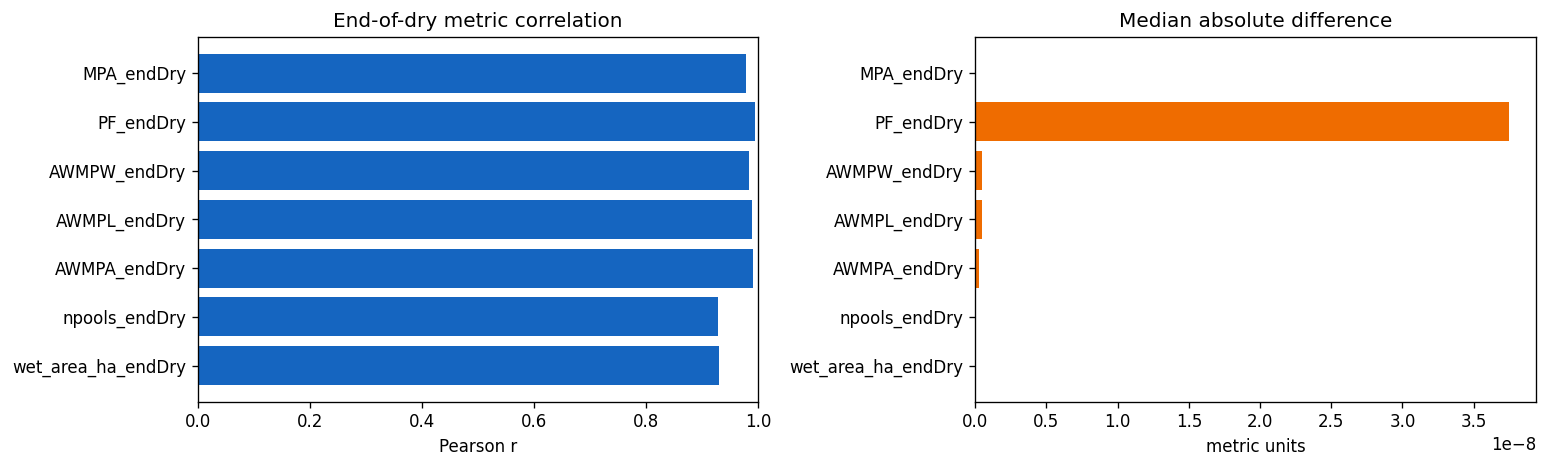

In [28]:
# Visual summary: end-of-dry metric correlation / absolute error
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
end_summary = metric_summary[metric_summary['metric'].isin(end_cols)].copy()

axes[0].barh(end_summary['metric'], end_summary['corr'], color='#1565C0')
axes[0].set_xlim(0, 1)
axes[0].set_title('End-of-dry metric correlation')
axes[0].set_xlabel('Pearson r')

axes[1].barh(end_summary['metric'], end_summary['median_abs_diff'], color='#EF6C00')
axes[1].set_title('Median absolute difference')
axes[1].set_xlabel('metric units')

plt.tight_layout()
plt.show()

## 9 — Config-file workflow

For reproducible runs and batch processing, HydroSeason accepts a YAML config.

In [29]:
import pathlib, textwrap

cfg_text = textwrap.dedent("""
    input:
      csv_path: ../tests/fixtures/DATASET2.csv   # only Rainfall_mm is used by the delineation step
      date_col: Date
      year_col: Year
      month_col: Month
      value_col: Rainfall_mm

    output:
      output_csv: ../output/tayer2026_delineated.csv

    algorithm:
      smooth_window: 3          # paper-spec (Tayer 2026)
      firstpass_quantile: 0.20
      secondpass_quantile: 0.10
      long_period_threshold: 16
      onset_window_months: 1
      method: circular           # circular (default) | kmeans (legacy)
      rainfall_si_override: true  # promote borderline STL to seasonal when Walsh-Lawler SI is strongly seasonal
      rainfall_si_threshold: 0.80

    validation:
      max_fraction_missing: 0.10
      max_gap_to_interpolate: 2
      raise_on_error: true
""").strip()

cfg_path = pathlib.Path('../output/example_config.yaml')
cfg_path.parent.mkdir(parents=True, exist_ok=True)
cfg_path.write_text(cfg_text, encoding='utf-8')
print('Wrote:', cfg_path)
print(cfg_text)


Wrote: ..\output\example_config.yaml
input:
  csv_path: ../tests/fixtures/DATASET2.csv   # only Rainfall_mm is used by the delineation step
  date_col: Date
  year_col: Year
  month_col: Month
  value_col: Rainfall_mm

output:
  output_csv: ../output/tayer2026_delineated.csv

algorithm:
  smooth_window: 3          # paper-spec (Tayer 2026)
  firstpass_quantile: 0.20
  secondpass_quantile: 0.10
  long_period_threshold: 16
  onset_window_months: 1
  method: circular           # circular (default) | kmeans (legacy)
  rainfall_si_override: true  # promote borderline STL to seasonal when Walsh-Lawler SI is strongly seasonal
  rainfall_si_threshold: 0.80

validation:
  max_fraction_missing: 0.10
  max_gap_to_interpolate: 2
  raise_on_error: true


In [30]:
from hydroseason.config import load_config
from hydroseason.pipeline import run_pipeline

# Note: run_pipeline reads the input CSV from the config's csv_path.
# We'll use classify_rainfall_from_file for the pre-loaded input_df instead.
from hydroseason import classify_rainfall_from_file

arts_csv = classify_rainfall_from_file(
    '../tests/fixtures/tayer2026_input.csv',
    output_csv='../output/tayer2026_delineated.csv',
)
print('Regime :', arts_csv.diagnostics.regime)
print('Rows   :', len(arts_csv.result))
print('Wrote  : ../output/tayer2026_delineated.csv')

Regime : seasonal
Rows   : 443
Wrote  : ../output/tayer2026_delineated.csv


## 10 — Export & next steps

Save the full annotated result and figures.

In [32]:
import json, pathlib

out_dir = pathlib.Path('../output')
out_dir.mkdir(exist_ok=True)

# Full annotated CSV
result.to_csv(out_dir / 'tayer2026_delineated.csv', index=False)

# Diagnostics sidecar
import dataclasses
(out_dir / 'tayer2026_diagnostics.json').write_text(
    json.dumps(dataclasses.asdict(diag), default=str, indent=2), encoding='utf-8'
)

# Plotly figures — PNG export requires kaleido; skip gracefully if not installed
try:
    import kaleido  # noqa: F401
    _plotly_figs = {
        'fig1_timeline.png':    fig_tl,
        'fig2_climatology.png': fig_clim,
        'fig3_stl.png':         fig_stl,
        'fig4_annual_metrics.png': fig_ann,
        'fig5_dashboard.png':   fig_dash,
    }
    for name, fig in _plotly_figs.items():
        fig.write_image(str(out_dir / name), scale=2)
    print('Plotly figures exported as PNG.')
except ImportError:
    print('kaleido not installed — PNG figure export skipped. Install with: pip install kaleido')

print('Exports:')
for p in sorted(out_dir.iterdir()):
    print(f'  {p.name:<45} {p.stat().st_size:>8,} bytes')


kaleido not installed — PNG figure export skipped. Install with: pip install kaleido
Exports:
  example_config.yaml                                735 bytes
  hydroseason_results.csv                         72,950 bytes
  hydroseason_results.HydroSeason.json               560 bytes
  smoke_demo.csv                                   5,168 bytes
  smoke_report.html                             3,794,323 bytes
  tayer2026_delineated.csv                        66,393 bytes
  tayer2026_diagnostics.json                         546 bytes


In [33]:
# Final summary table: per-hydro-year metrics
annual_summary = (
    result
    .drop_duplicates(subset=['Hydro_Year'])
    [['Hydro_Year', 'wet_total', 'dry_total', 'wet_month_count', 'dry_month_count']]
    .sort_values('Hydro_Year')
    .reset_index(drop=True)
)
annual_summary.columns = ['Hydro Year', 'Wet Total (mm)', 'Dry Total (mm)',
                           'Wet Months', 'Dry Months']
display(annual_summary.style.background_gradient(
    subset=['Wet Total (mm)', 'Dry Total (mm)'], cmap='Blues'
).format({'Wet Total (mm)': '{:.0f}', 'Dry Total (mm)': '{:.0f}'}))

,Hydro Year,Wet Total (mm),Dry Total (mm),Wet Months,Dry Months
0,1987,642,0,6,4
1,1988,180,50,6,7
2,1989,705,0,9,2
3,1990,650,0,9,4
4,1991,1054,0,4,8
5,1992,430,16,5,7
6,1993,573,32,5,7
7,1994,516,0,5,6
8,1995,737,22,7,5
9,1996,368,0,7,5
